In [1]:
import os
os.chdir(r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\notebooks')
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\data\ecommerce.db'
print("✅ ready")

✅ ready


In [2]:
con = duckdb.connect(DB_PATH)
df = con.execute("""
    SELECT
        customer_unique_id,
        order_id,
        order_purchase_timestamp,
        payment_value
    FROM stg_order_details
    WHERE order_purchase_timestamp IS NOT NULL
""").df()
con.close()

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
print(f"Rows: {len(df):,}")
print(df.head(3))

Rows: 110,197
                 customer_unique_id                          order_id  \
0  871766c5855e863f6eccc05f988b23cb  00010242fe8c5a6d1ba2dd792cb16214   
1  3818d81c6709e39d06b2738a8d3a2474  000229ec398224ef6ca0657da4fc703e   
2  af861d436cfc08b2c2ddefd0ba074622  00024acbcdf0a6daa1e931b038114c75   

  order_purchase_timestamp  payment_value order_month  
0      2017-09-13 08:59:02          72.19     2017-09  
1      2018-01-14 14:33:31         216.87     2018-01  
2      2018-08-08 10:00:35          25.78     2018-08  


In [3]:
# First order month per customer = cohort
cohort_df = (
    df.groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
)
cohort_df.columns = ['customer_unique_id', 'cohort_month']

# Merge back
df = df.merge(cohort_df, on='customer_unique_id')

# Cohort index = months since first purchase
df['cohort_index'] = (
    df['order_month'] - df['cohort_month']
).apply(lambda x: x.n)

print(df[['customer_unique_id','order_month',
          'cohort_month','cohort_index']].head(5))

                 customer_unique_id order_month cohort_month  cohort_index
0  871766c5855e863f6eccc05f988b23cb     2017-09      2017-09             0
1  3818d81c6709e39d06b2738a8d3a2474     2018-01      2018-01             0
2  af861d436cfc08b2c2ddefd0ba074622     2018-08      2018-08             0
3  64b576fb70d441e8f1b2d7d446e483c5     2017-02      2017-02             0
4  85c835d128beae5b4ce8602c491bf385     2017-05      2017-05             0


In [4]:
cohort_pivot = (
    df.groupby(['cohort_month','cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_matrix = cohort_pivot.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

# Keep only cohorts with enough data
cohort_matrix = cohort_matrix.iloc[:-3]  # drop last 3 incomplete months

# Retention % = divide each row by cohort size (column 0)
cohort_size    = cohort_matrix[0]
retention_pct  = cohort_matrix.divide(cohort_size, axis=0).round(3) * 100

print(f"Cohort matrix shape: {retention_pct.shape}")
print(retention_pct.iloc[:5, :6])

Cohort matrix shape: (20, 20)
cohort_index      0      1    2    3    4    5
cohort_month                                  
2016-09       100.0    NaN  NaN  NaN  NaN  NaN
2016-10       100.0    NaN  NaN  NaN  NaN  NaN
2016-12       100.0  100.0  NaN  NaN  NaN  NaN
2017-01       100.0    0.3  0.3  0.1  0.4  0.1
2017-02       100.0    0.2  0.3  0.1  0.4  0.1


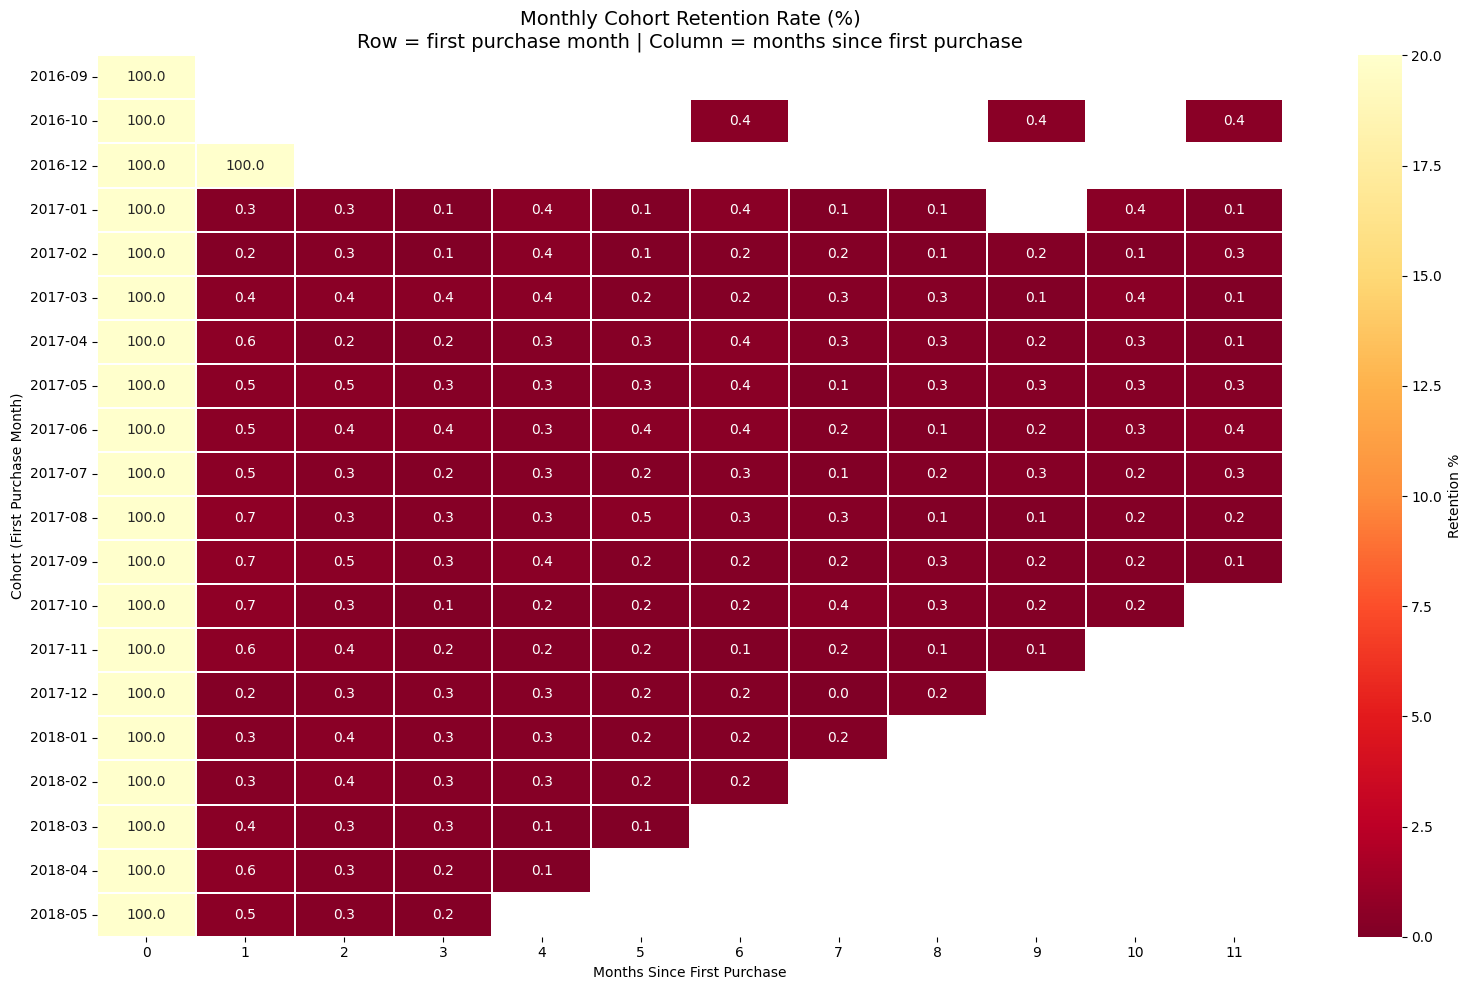

In [5]:
fig, ax = plt.subplots(figsize=(16, 10))

# Show first 12 months only
retention_plot = retention_pct.iloc[:, :12]

sns.heatmap(
    retention_plot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Retention %'},
    vmin=0, vmax=20
)

ax.set_title(
    'Monthly Cohort Retention Rate (%)\n'
    'Row = first purchase month | Column = months since first purchase',
    fontsize=14
)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
ax.set_yticklabels(
    [str(x) for x in retention_plot.index],
    rotation=0
)

plt.tight_layout()
plt.savefig('../data/cohort_retention.png')
plt.show()

In [8]:
print("=" * 50)
print("COHORT RETENTION SUMMARY")
print("=" * 50)
print(f"Month 0 (first purchase):  {avg_retention[0]:.1f}%")
print(f"Month 1 retention:         {avg_retention.get(1,0):.1f}%")
print(f"Month 2 retention:         {avg_retention.get(2,0):.1f}%")
print(f"Month 3 retention:         {avg_retention.get(3,0):.1f}%")
print(f"Month 6 retention:         {avg_retention.get(6,0):.1f}%")
print(f"Month 12 retention:        {avg_retention.get(12,0):.1f}%")
print("=" * 50)
print("\nKEY INSIGHT:")
print("6% Month-1 retention confirms Olist is primarily")
print("a single-purchase marketplace, not subscription-style.")
print("Customer acquisition > retention is the growth lever.")
print(f"\nBest cohort (Dec 2016): 100% — only 1 customer, ignore.")
print(f"Worst cohort (Feb 2017): 0.2% — largest cohort, most reliable.")
print("\nIndustry benchmark: 20-30% Month-1 = healthy e-commerce.")
print("Olist at 6% = massive retention gap = opportunity.")

COHORT RETENTION SUMMARY
Month 0 (first purchase):  100.0%
Month 1 retention:         6.0%
Month 2 retention:         0.3%
Month 3 retention:         0.2%
Month 6 retention:         0.3%
Month 12 retention:        0.2%

KEY INSIGHT:
6% Month-1 retention confirms Olist is primarily
a single-purchase marketplace, not subscription-style.
Customer acquisition > retention is the growth lever.

Best cohort (Dec 2016): 100% — only 1 customer, ignore.
Worst cohort (Feb 2017): 0.2% — largest cohort, most reliable.

Industry benchmark: 20-30% Month-1 = healthy e-commerce.
Olist at 6% = massive retention gap = opportunity.


In [9]:
# Save cohort matrix to DB for dashboard
cohort_save = retention_pct.reset_index()
cohort_save['cohort_month'] = cohort_save['cohort_month'].astype(str)

parquet = r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\data\cohort_retention.parquet'
cohort_save.to_parquet(parquet, index=False)

con = duckdb.connect(DB_PATH)
con.execute("DROP TABLE IF EXISTS cohort_retention")
con.execute(f"""
    CREATE TABLE cohort_retention AS
    SELECT * FROM read_parquet('{parquet.replace(chr(92),'/')}')
""")
print(f"✅ cohort_retention saved — {len(cohort_save)} cohorts")
con.close()

✅ cohort_retention saved — 20 cohorts
